In [1]:
import pandas as pd
import csv
from itertools import combinations
import matplotlib.pyplot as plt
import os
import gzip
from tqdm import tqdm
csv.field_size_limit(100000000000000000)

131072

In [ ]:
# download the files to data/
# https://download.jensenlab.org/human_textmining_mentions.tsv
# https://download.jensenlab.org/disease_textmining_mentions.tsv

In [2]:
# extract all the text-mining links
all_positives = set()
# 1. extract all the positive proteins, we only consider the positive proteins
for f in os.listdir('data/test'):
    file = f'data/test/{f}'
    df_gold_standard = pd.read_csv(file, sep='\t', header=None)
    pos_proteins = df_gold_standard[df_gold_standard.iloc[:,1] == 1].iloc[:,0].values.tolist()
    all_positives.update(set(pos_proteins)) 

In [5]:
text_mining_edges = set()
with gzip.open('data/9606.protein.links.detailed.v12.0.txt.gz', 'rb') as f:
    for idx,line in enumerate(f):
        if idx == 0:
            continue
        line = line.decode('utf-8').strip().split(' ')

        protein1 = line[0]
        protein2 = line[1]
        text_score = float(line[-2])
        if text_score > 0:
            text_mining_edges.add((protein1,protein2))

In [3]:
def query_disease(query_ids):
    results = dict()
    with open('data/disease_textmining_mentions.tsv','r') as f:
        reader = csv.reader(f, delimiter='\t')
        
        for row in reader:
            disease_id = row[0]
            if disease_id in query_ids:
                pubmed_ids = row[1].split(' ')
                results[disease_id] = pubmed_ids
    return results

In [4]:
disease2ids = {
    'aortic_aneurysm':'DOID:3627',
    'atopic_dermatitis': 'DOID:3310',
    'colorectal_adenocarcinoma': 'DOID:0050861',
    'diffuse_large_b-cell_lymphoma': 'DOID:0050745',
    'focal_epilepsy':'DOID:2234',
    'melanoma': 'DOID:1909',
    'ulcerative_colitis': 'DOID:8577'
}

doid_results = query_disease(disease2ids.values())

In [8]:
df_protein_text_mining = pd.read_csv('data/human_textmining_mentions.tsv', sep='\t',header=None)

In [10]:
protein_to_pmids = {
    row.iloc[0]: set(row.iloc[1].split(' '))
    for _, row in df_protein_text_mining.iterrows()
}

In [11]:
results_summary = []
for disease in disease2ids.keys():
    print(f'Processing {disease}')
    file = f'data/test/{disease}.gold_standard.balanced.tsv'
    df_gold_standard = pd.read_csv(file, sep='\t', header=None)
    pos_proteins = [p.split('.')[1] for p in df_gold_standard[df_gold_standard.iloc[:,1] == 1].iloc[:,0]]
    disease_pubmed_ids = set(doid_results[disease2ids[disease]])
    
    all_percentages = set()
    protein_pairs = list(combinations(pos_proteins, 2))
    for protein1, protein2 in tqdm(protein_pairs):
        
        # protein1 and protein2 must have a text-mining link
        if (f'9606.{protein1}', f'9606.{protein2}') not in text_mining_edges or (f'9606.{protein2}', f'9606.{protein1}') not in text_mining_edges:
            continue
        
        comention_papers = protein_to_pmids.get(protein1, set()) & protein_to_pmids.get(protein2, set())
        
        mentioned_disease = comention_papers & disease_pubmed_ids
        
        if len(comention_papers) == 0 or len(mentioned_disease) == 0:
            continue
        disease_percent = len(mentioned_disease) / len(comention_papers)
                
        all_percentages.add(disease_percent)
    
    results_summary.append([disease, all_percentages])

Processing aortic_aneurysm


100%|██████████| 4753/4753 [00:02<00:00, 1896.74it/s]


Processing atopic_dermatitis


100%|██████████| 17578/17578 [00:04<00:00, 3777.09it/s]


Processing colorectal_adenocarcinoma


...

100%|██████████| 7260/7260 [00:01<00:00, 4388.90it/s]


Processing melanoma


100%|██████████| 81406/81406 [00:03<00:00, 26220.79it/s]


Processing ulcerative_colitis


100%|██████████| 21736/21736 [00:05<00:00, 3788.23it/s]


In [12]:
## studiedness of a single protein
single_protein_results = list()
# for f in os.listdir('data/test'):
for disease in disease2ids.keys():
    file = f'data/test/{disease}.gold_standard.balanced.tsv'
    df_gold_standard = pd.read_csv(file, sep='\t', header=None)
    pos_proteins = df_gold_standard[df_gold_standard.iloc[:,1] == 1].iloc[:,0].values.tolist()
    disease_id = disease2ids[disease]
    disease_pmids = set(doid_results[disease_id])
    
    single_disease_results = list()
    for protein in pos_proteins:
        protein = protein.split('.')[1]
        protein_pmids = set(protein_to_pmids[protein])
        disease_mention_percentage = len(disease_pmids & protein_pmids) / len(protein_pmids)
        single_disease_results.append(disease_mention_percentage)
    single_protein_results.append([disease,single_disease_results])

# Define desired order
disease_order = [
    'atopic_dermatitis',
    'ulcerative_colitis',
    'focal_epilepsy',
    'colorectal_adenocarcinoma',
    'diffuse_large_b-cell_lymphoma',
    'melanoma',
    'aortic_aneurysm'
]

# Reorder results_summary and single_protein_results
results_dict = {x[0]: x[1] for x in results_summary}
results_summary_ordered = [(d, results_dict[d]) for d in disease_order if d in results_dict]

single_dict = {x[0]: x[1] for x in single_protein_results}
single_protein_results_ordered = [(d, single_dict[d]) for d in disease_order if d in single_dict]

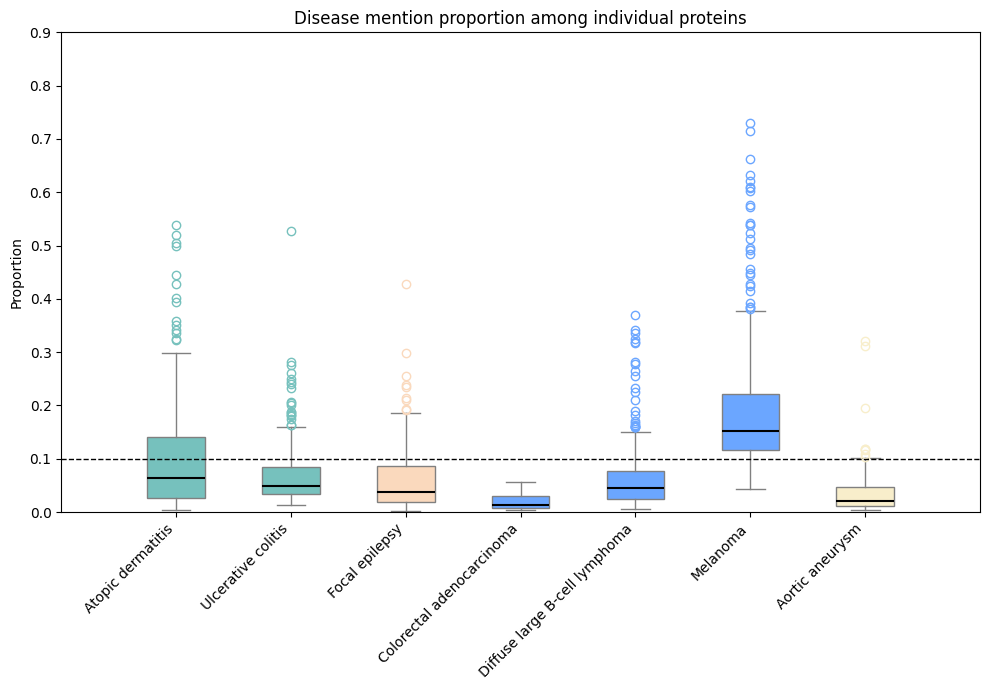

In [13]:
colors = ['#76c1bd', '#fad9bd', '#6ba6ff', '#f8eecb']
disease2color = {
    'atopic_dermatitis': colors[0],
    'ulcerative_colitis': colors[0],
    'focal_epilepsy': colors[1],
    'colorectal_adenocarcinoma': colors[2],
    'melanoma': colors[2],
    'diffuse_large_b-cell_lymphoma': colors[2],
    'aortic_aneurysm': colors[3]
}

def format_label(disease):
    display = disease.replace('_', ' ').capitalize()
    if 'b-cell' in display:
        display = display.replace('b-cell', 'B-cell')
    return display

def color_boxplot(bp, disease_names, disease2color):
    for i, disease in enumerate(disease_names):
        color = disease2color.get(disease, '#cccccc')
        bp['boxes'][i].set_color(color)
        bp['boxes'][i].set_linewidth(1.5)
        bp['medians'][i].set_color('black')
        bp['medians'][i].set_linewidth(1.5)
        for key in ['whiskers', 'caps']:
            bp[key][2*i].set_color(color)
            bp[key][2*i+1].set_color(color)
        bp['fliers'][i].set_markeredgecolor(color)

fig, (ax2) = plt.subplots(1, 1, figsize=(10, 7))

# Right panel: Single Protein
disease_names_single = [x[0] for x in single_protein_results_ordered]
xlabels_single = [format_label(d) for d in disease_names_single]
bp2 = ax2.boxplot([list(x[1]) for x in single_protein_results_ordered], patch_artist=True)
for i, disease in enumerate(disease_names_single):
    c = disease2color.get(disease, '#cccccc')
    bp2['boxes'][i].set_facecolor(c)
    bp2['boxes'][i].set_edgecolor('grey')
    bp2['medians'][i].set_color('black')
    bp2['medians'][i].set_linewidth(1.5)
    for key in ['whiskers', 'caps']:
        bp2[key][2*i].set_color('grey')
        bp2[key][2*i+1].set_color('grey')
    bp2['fliers'][i].set_markeredgecolor(c)
ax2.hlines([0.1], 0, len(single_protein_results_ordered)+1, colors='k', linestyles='dashed', linewidth=1)
ax2.set_xticks(range(1, len(single_protein_results_ordered)+1))
ax2.set_xticklabels(xlabels_single, rotation=45, ha='right')
ax2.set_ylabel('Proportion')
ax2.set_xlim(0, len(single_protein_results_ordered)+1)
ax2.set_ylim(0, 0.9)
ax2.set_title('Disease mention proportion among individual proteins')

plt.tight_layout()
plt.savefig('results/supp_figures/comention_proportion.png', bbox_inches='tight', dpi=300)
plt.show()